In [634]:
import pandas as pd
import numpy as np
import seaborn as sns
import ast
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import string
import re
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.probability import FreqDist
import pymorphy3
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [226]:
df = pd.read_csv('posts_TV_BRICS.csv', index_col = 0)
df.head()

,post_id,date,post_text
0,45100,2026-01-22,«Зерно БРИКС». Ячмень
1,45126,2026-01-23,🇮🇳🧠 Команда биоинженеров из Индии запустила дв...
2,45124,2026-01-23,"🇻🇳📈 Экспорт компьютеров, электроники и компле..."
3,45123,2026-01-23,NaN
4,45122,2026-01-23,🇦🇪 ОАЭ планируют к 2027 году внедрить системы...


In [228]:
df.dropna(inplace=True)

In [246]:
stop_words = stopwords.words('russian')

In [236]:
morph = pymorphy3.MorphAnalyzer()

In [238]:
def tokenize_text(raw_text: str):
    """Функция для токенизации текста
    :param raw_text: исходная текстовая строка
    """
    # Разбиение на сслова при помощи пробела
    words = raw_text.split()
    # Подготовка регулярного выражения для фильтрации символов
    re_punc = re.compile('[%s]' % re.escape(string.punctuation))
    # Удаление знаков препинания
    stripped = [re_punc.sub('', w) for w in words]
    # Приведение всех слов к нижнему регистру
    words_lower = [w.lower() for w in stripped]
    # Удаление оставшихся токенов, которые не являются буквами
    words_alpha = [word for word in words_lower if word.isalpha()]
    # Удаление стоп-слов    
    words_stop = [w for w in words_alpha if not w in stop_words]
    # Лемматизация    
    tokens = [morph.parse(token)[0].normal_form for token in words_stop]
    # Удалим короткие токены
    tokens = [word for word in tokens if len(word) > 2]
      
    return tokens

In [240]:
df.tail()

,post_id,date,post_text
17064,18111,2018-01-24,Жаркая бразильская вечеринка посреди зимы. Фес...
17065,18110,2018-01-24,#tvbrics #цитата #оскарнимейер #бразилия #БРИКС
17066,18109,2018-01-24,Российские отельеры готовятся к наплыву индийс...
17067,18108,2018-01-24,В Китае разработали стратегию по ликвидации бе...
17068,18103,2018-01-24,"Смотрите на #TVBRICS сегодня, 24 января: \n \n..."


In [242]:
# применяем функцию к датафрейму с помощью метода .apply()
tokenized= df['post_text'].apply(tokenize_text)

In [243]:
# добавляем новую колонку в исходный датафрейм
df = df.assign(tokenized=tokenized)
df.head()

,post_id,date,post_text,tokenized
0,45100,2026-01-22,«Зерно БРИКС». Ячмень,[ячмень]
1,45126,2026-01-23,🇮🇳🧠 Команда биоинженеров из Индии запустила дв...,"[команда, биоинженер, индия, запустить, два, и..."
2,45124,2026-01-23,"🇻🇳📈 Экспорт компьютеров, электроники и компле...","[экспорт, компьютер, электроника, комплектующи..."
4,45122,2026-01-23,🇦🇪 ОАЭ планируют к 2027 году внедрить системы...,"[оаэ, планировать, год, внедрить, система, иск..."
5,45121,2026-01-23,«Режим питания нарушать нельзя»: как и сколько...,"[питание, нарушать, сколько, есть, космонавт, ..."


In [17]:
df.to_csv('tvBRICS_posts_tokens.csv')

In [19]:
words_list_posts = list(df['tokenized'])

In [21]:
all_words_posts = np.concatenate(words_list_posts)

In [23]:
all_words_freq_posts = FreqDist(all_words_posts)
print("Наиболлее популярные слова: ", all_words_freq_posts.most_common(100))
print("\nОбщее количество уникальных слов: ", len(all_words_freq_posts.keys()))

Наиболлее популярные слова:  [('страна', 6838), ('год', 6355), ('россия', 5714), ('брикс', 5093), ('brics', 4163), ('китай', 3829), ('новый', 3232), ('the', 3225), ('индия', 3219), ('подробный', 3114), ('который', 3029), ('международный', 2808), ('наш', 2585), ('бразилия', 2551), ('российский', 2360), ('развитие', 2340), ('проект', 2119), ('это', 2003), ('сотрудничество', 1929), ('юар', 1899), ('также', 1886), ('программа', 1856), ('стать', 1840), ('первый', 1781), ('китайский', 1692), ('мир', 1642), ('смотреть', 1519), ('город', 1501), ('свой', 1406), ('москва', 1381), ('материал', 1380), ('пройти', 1282), ('президент', 1279), ('самый', 1276), ('новость', 1243), ('tvbrics', 1234), ('время', 1192), ('человек', 1158), ('день', 1154), ('один', 1152), ('технология', 1146), ('работа', 1145), ('подробно', 1115), ('министр', 1109), ('национальный', 1100), ('африка', 1072), ('область', 1063), ('сеть', 1062), ('выпуск', 1048), ('заявить', 1030), ('культура', 999), ('мероприятие', 998), ('учёны

C:\Temp\ipykernel_10828\3957900171.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


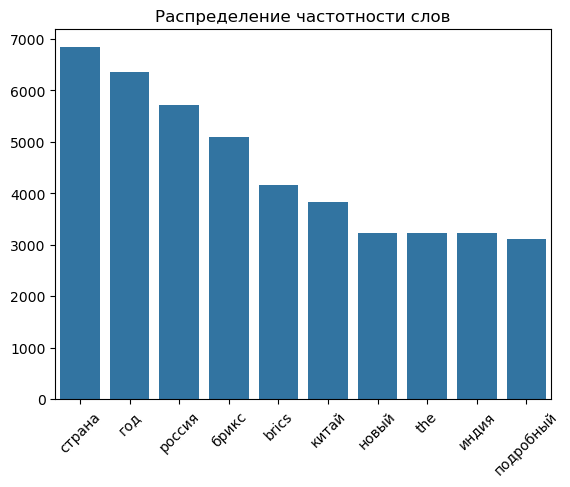

In [25]:
count, words = [], []
for w in all_words_freq_posts.most_common(10):
    words.append(w[0])
    count.append(w[1])

ax = sns.barplot(x=words,y=count)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_title ('Распределение частотности слов')
plt.show()

In [737]:
df = pd.read_csv('tvBRICS_posts_tokens.csv',index_col=0)
df.head()

,post_id,date,post_text,tokenized,tokens
0,45100,2026-01-22,«Зерно БРИКС». Ячмень,['ячмень'],['ячмень']
1,45126,2026-01-23,🇮🇳🧠 Команда биоинженеров из Индии запустила дв...,"['команда', 'биоинженер', 'индия', 'запустить'...","['команда', 'биоинженер', 'индия', 'запустить'..."
2,45124,2026-01-23,"🇻🇳📈 Экспорт компьютеров, электроники и компле...","['экспорт', 'компьютер', 'электроника', 'компл...","['экспорт', 'компьютер', 'электроника', 'компл..."
4,45122,2026-01-23,🇦🇪 ОАЭ планируют к 2027 году внедрить системы...,"['оаэ', 'планировать', 'внедрить', 'система', ...","['оаэ', 'планировать', 'внедрить', 'система', ..."
5,45121,2026-01-23,«Режим питания нарушать нельзя»: как и сколько...,"['питание', 'нарушать', 'сколько', 'есть', 'ко...","['питание', 'нарушать', 'сколько', 'космонавт'..."


In [739]:
stop_words_ex = ['год','наш', 'который', 'есть','также','the', 'фильм', 'программа', 'tvbrics', 'смотреть', 'это', 'выпуск', 'подробно', 
                 'документальный', 'режиссёр', 'программа', 'эфир', 'опубликовать', 'ведущий', 'фестивальный',  'видео', 'разместить', 'эксклюзивный', 
                 'история', 'эфир', 'портал','учёный', 'первый', 'млрд', 'подробно', 'новый', 'подробный', 'фестиваль', 'твбрикс', 'новость', 'сам', 
                 'сериал', 'мультфильм', 'информация', 'rutube', 'telegramканал', 'курс', 'анимация', 'httpstmetvbrics','httpstmeroscosmosgk',
                'and', 'какой','млн','тонна','сюжет']

In [731]:
words_list_posts = list(df['tokenized'])

In [700]:
words_list_posts[:5]

["['ячмень']",
 "['команда', 'биоинженер', 'индия', 'запустить', 'два', 'интеллектуальный', 'платформа', 'помогать', 'исследователь', 'изучать', 'заболевание', 'мозг', 'находить', 'биомаркер', 'разрабатывать', 'лекарство', 'первый', 'платформа', 'brainprot', 'объединять', 'биологический', 'дать', 'разный', 'источник', 'единый', 'база', 'содержать', 'информация', 'заболевание', 'мозг', 'набор', 'данные', 'различный', 'область', 'молекулярный', 'биология', 'позволять', 'изучать', 'работа', 'мозг', 'нормальный', 'состояние', 'время', 'изменение', 'возникать', 'заболевание', 'второй', 'платформа', 'drugprotai', 'предназначить', 'оценка', 'белок', 'стать', 'мишень', 'лекарство', 'учёт', 'биологический', 'физикохимический', 'свойство', 'интеграция', 'два', 'система', 'позволять', 'исследователь', 'час', 'пройти', 'путь', 'выявление', 'маркер', 'заболевание', 'анализ', 'изменение', 'активность', 'ген']",
 "['экспорт', 'компьютер', 'электроника', 'комплектующие', 'вьетнам', 'превысить', 'трлн'

In [702]:
len(words_list_posts)

16358

In [741]:
words_list=[]
for i in range(len(words_list_posts)):
    words_list.append(ast.literal_eval(words_list_posts[i]))

In [743]:
print(words_list[:5])

[['ячмень'], ['команда', 'биоинженер', 'индия', 'запустить', 'два', 'интеллектуальный', 'платформа', 'помогать', 'исследователь', 'изучать', 'заболевание', 'мозг', 'находить', 'биомаркер', 'разрабатывать', 'лекарство', 'первый', 'платформа', 'brainprot', 'объединять', 'биологический', 'дать', 'разный', 'источник', 'единый', 'база', 'содержать', 'информация', 'заболевание', 'мозг', 'набор', 'данные', 'различный', 'область', 'молекулярный', 'биология', 'позволять', 'изучать', 'работа', 'мозг', 'нормальный', 'состояние', 'время', 'изменение', 'возникать', 'заболевание', 'второй', 'платформа', 'drugprotai', 'предназначить', 'оценка', 'белок', 'стать', 'мишень', 'лекарство', 'учёт', 'биологический', 'физикохимический', 'свойство', 'интеграция', 'два', 'система', 'позволять', 'исследователь', 'час', 'пройти', 'путь', 'выявление', 'маркер', 'заболевание', 'анализ', 'изменение', 'активность', 'ген'], ['экспорт', 'компьютер', 'электроника', 'комплектующие', 'вьетнам', 'превысить', 'трлн', 'рубл

In [745]:
tokens=[]    
for i in range(len(words_list)):
    tokens.append(stop_words_extra(words_list [i]))    

In [747]:
print(tokens[4])

['питание', 'нарушать', 'сколько', 'космонавт', 'мкс', 'полугодовой', 'экспедиция', 'космонавт', 'делиться', 'цикл', 'день', 'течение', 'каждый', 'суточный', 'рацион', 'состоять', 'разный', 'заранее', 'утвердить', 'основный', 'блюдо', 'передумать', 'съесть', 'вместо', 'рыба', 'булочка', 'нежелательно', 'нарушиться', 'баланс', 'кбзить', 'важный', 'составлять', 'здоровье', 'отправляться', 'мкс', 'космонавт', 'брать', 'себя', 'тип', 'контейнер', 'продукт', 'основный', 'меню', 'дополнительный', 'любимый', 'еда', 'дополнительный', 'контейнер', 'формироваться', 'блюдо', 'получить', 'высокий', 'оценка', 'дегустация', 'каждый', 'космонавт', 'шесть', 'такой', 'контейнер', 'штатный', 'бортовый', 'рацион', 'включать', 'около', 'наименование', 'продукт', 'напиток', 'больший', 'часть', 'сублимировать', 'источник', 'единственный', 'официальный', 'телеграмканал', 'госкорпорация']


In [749]:
df['tokens'] = tokens

In [751]:
df.head()

,post_id,date,post_text,tokenized,tokens
0,45100,2026-01-22,«Зерно БРИКС». Ячмень,['ячмень'],[ячмень]
1,45126,2026-01-23,🇮🇳🧠 Команда биоинженеров из Индии запустила дв...,"['команда', 'биоинженер', 'индия', 'запустить'...","[команда, биоинженер, индия, запустить, два, и..."
2,45124,2026-01-23,"🇻🇳📈 Экспорт компьютеров, электроники и компле...","['экспорт', 'компьютер', 'электроника', 'компл...","[экспорт, компьютер, электроника, комплектующи..."
4,45122,2026-01-23,🇦🇪 ОАЭ планируют к 2027 году внедрить системы...,"['оаэ', 'планировать', 'внедрить', 'система', ...","[оаэ, планировать, внедрить, система, искусств..."
5,45121,2026-01-23,«Режим питания нарушать нельзя»: как и сколько...,"['питание', 'нарушать', 'сколько', 'есть', 'ко...","[питание, нарушать, сколько, космонавт, мкс, п..."


Много стоп-слов, связанных с телепередачами, документадбными фильмами и пр. Видно в сообществе много анонсов видеопрограмм

In [753]:
all_words_posts = list(df['tokens'])

In [755]:
all_words_posts = np.concatenate(all_words_posts)

In [757]:
all_words_freq_posts = FreqDist(all_words_posts)
print("Наиболлее популярные слова: ", all_words_freq_posts.most_common(100))
print("\nОбщее количество уникальных слов: ", len(all_words_freq_posts.keys()))

Наиболлее популярные слова:  [('страна', 6838), ('россия', 5714), ('брикс', 5093), ('brics', 4163), ('китай', 3829), ('индия', 3219), ('международный', 2808), ('бразилия', 2551), ('российский', 2360), ('развитие', 2340), ('проект', 2119), ('сотрудничество', 1929), ('юар', 1899), ('стать', 1840), ('китайский', 1692), ('мир', 1642), ('город', 1501), ('свой', 1406), ('москва', 1381), ('материал', 1380), ('пройти', 1282), ('президент', 1279), ('самый', 1276), ('время', 1192), ('человек', 1158), ('день', 1154), ('один', 1152), ('технология', 1146), ('работа', 1145), ('министр', 1109), ('национальный', 1100), ('африка', 1072), ('область', 1063), ('сеть', 1062), ('заявить', 1030), ('культура', 999), ('мероприятие', 998), ('партнёр', 980), ('сегодня', 973), ('участие', 945), ('встреча', 939), ('принять', 919), ('центр', 918), ('форум', 914), ('рассказать', 913), ('крупный', 907), ('создать', 907), ('сфера', 899), ('экономический', 890), ('система', 886), ('государство', 885), ('отметить', 881)

C:\Temp\ipykernel_10828\1140197026.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


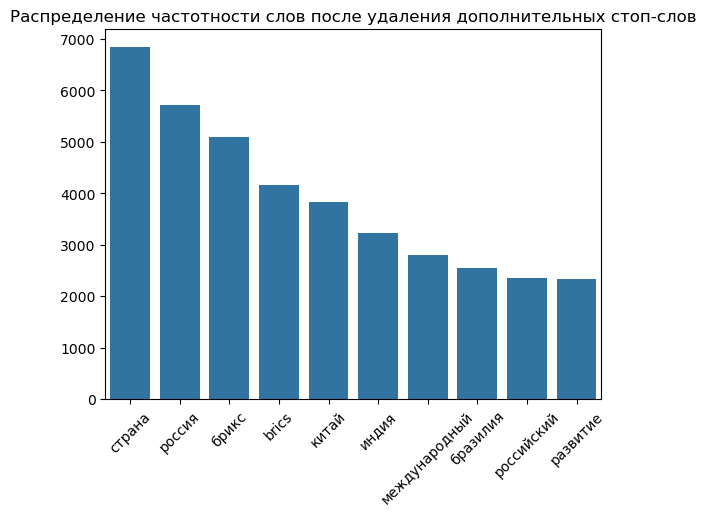

In [759]:
count, words = [], []
for w in all_words_freq_posts.most_common(10):
    words.append(w[0])
    count.append(w[1])

ax = sns.barplot(x=words,y=count)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_title ('Распределение частотности слов после удаления дополнительных стоп-слов')
plt.show()

In [761]:
df.to_csv('tvBRICS_posts_tokens.csv')

In [763]:
df = pd.read_csv('tvBRICS_posts_tokens.csv',index_col=0)
df.head()

,post_id,date,post_text,tokenized,tokens
0,45100,2026-01-22,«Зерно БРИКС». Ячмень,['ячмень'],['ячмень']
1,45126,2026-01-23,🇮🇳🧠 Команда биоинженеров из Индии запустила дв...,"['команда', 'биоинженер', 'индия', 'запустить'...","['команда', 'биоинженер', 'индия', 'запустить'..."
2,45124,2026-01-23,"🇻🇳📈 Экспорт компьютеров, электроники и компле...","['экспорт', 'компьютер', 'электроника', 'компл...","['экспорт', 'компьютер', 'электроника', 'компл..."
4,45122,2026-01-23,🇦🇪 ОАЭ планируют к 2027 году внедрить системы...,"['оаэ', 'планировать', 'внедрить', 'система', ...","['оаэ', 'планировать', 'внедрить', 'система', ..."
5,45121,2026-01-23,«Режим питания нарушать нельзя»: как и сколько...,"['питание', 'нарушать', 'сколько', 'есть', 'ко...","['питание', 'нарушать', 'сколько', 'космонавт'..."


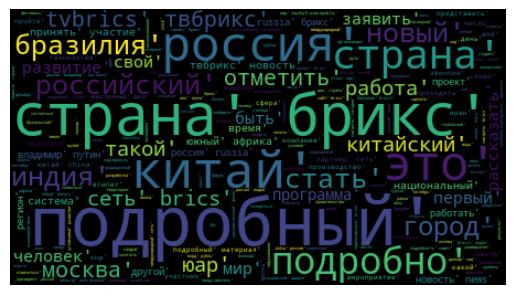

In [765]:
textt = ''.join(w for w in df.tokenized)
wordcloud = WordCloud(width=450,height=250).generate(textt)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

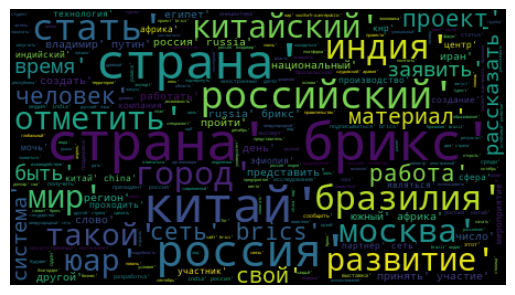

In [767]:
textt = ''.join(w for w in df.tokens)
wordcloud = WordCloud(width=450,height=250).generate(textt)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [63]:
# Приводим текст в векторное представление
tfidf_vect = TfidfVectorizer(max_df=1.0, min_df=2, stop_words=None)
doc_term_matrix = tfidf_vect.fit_transform(df.tokenized)

In [65]:
LDA = LatentDirichletAllocation(n_components=2, random_state=42)
LDA.fit(doc_term_matrix)
for i,topic in enumerate(LDA.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['сотрудничество', 'развитие', 'бразилия', 'международный', 'китай', 'индия', 'подробный', 'россия', 'брикс', 'страна']


Top 10 words for topic #1:
['учёный', 'китайский', 'это', 'фильм', 'город', 'выпуск', 'подробно', 'смотреть', 'brics', 'новый']




In [66]:
LDA = LatentDirichletAllocation(n_components=3, random_state=42)
LDA.fit(doc_term_matrix)
for i,topic in enumerate(LDA.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['китай', 'brics', 'индия', 'сотрудничество', 'развитие', 'международный', 'подробный', 'россия', 'брикс', 'страна']


Top 10 words for topic #1:
['документальный', 'сегодня', 'режиссёр', 'программа', 'история', 'эфир', 'выпуск', 'смотреть', 'brics', 'фильм']


Top 10 words for topic #2:
['новый', 'это', 'млн', 'подробно', 'tvbrics', 'подробный', 'бразилия', 'индия', 'россия', 'китай']




In [67]:
LDA = LatentDirichletAllocation(n_components=4, random_state=42)
LDA.fit(doc_term_matrix)
for i,topic in enumerate(LDA.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['президент', 'brics', 'индия', 'сотрудничество', 'международный', 'подробный', 'развитие', 'россия', 'брикс', 'страна']


Top 10 words for topic #1:
['опубликовать', 'ведущий', 'фестивальный', 'брикс', 'видео', 'разместить', 'эксклюзивный', 'история', 'эфир', 'портал']


Top 10 words for topic #2:
['учёный', 'индия', 'первый', 'это', 'млрд', 'подробно', 'новый', 'млн', 'китай', 'подробный']


Top 10 words for topic #3:
['китай', 'фестиваль', 'твбрикс', 'новость', 'брикс', 'россия', 'tvbrics', 'фильм', 'смотреть', 'brics']




In [68]:
LDA = LatentDirichletAllocation(n_components=5, random_state=42)
LDA.fit(doc_term_matrix)
for i,topic in enumerate(LDA.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['brics', 'индия', 'президент', 'международный', 'подробный', 'сотрудничество', 'развитие', 'россия', 'брикс', 'страна']


Top 10 words for topic #1:
['актуальный', 'сам', 'сериал', 'мультфильм', 'информация', 'rutube', 'telegramканал', 'курс', 'анимация', 'httpstmetvbrics']


Top 10 words for topic #2:
['вырасти', 'индия', 'россия', 'подробно', 'первый', 'новый', 'млрд', 'млн', 'китай', 'подробный']


Top 10 words for topic #3:
['china', 'фестиваль', 'смотреть', 'китай', 'твбрикс', 'tvbrics', 'россия', 'брикс', 'новость', 'brics']


Top 10 words for topic #4:
['древний', 'программа', 'китайский', 'индиец', 'традиция', 'фильм', 'город', 'смотреть', 'сегодня', 'история']




In [769]:
# Приводим текст в векторное представление
tfidf_vect = TfidfVectorizer(max_df=1.0, min_df=2, stop_words=None)
doc_term_matrix = tfidf_vect.fit_transform(df.tokens)

In [771]:
LDA = LatentDirichletAllocation(n_components=2, random_state=42)
LDA.fit(doc_term_matrix)
for i,topic in enumerate(LDA.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['юар', 'рубль', 'производство', 'город', 'самый', 'вырасти', 'бразилия', 'россия', 'индия', 'китай']


Top 10 words for topic #1:
['пройти', 'российский', 'индия', 'сотрудничество', 'развитие', 'международный', 'brics', 'россия', 'брикс', 'страна']




In [773]:
topic_values = LDA.transform(doc_term_matrix)
topic_values.shape

(16358, 2)

In [775]:
df['Topic_LDA'] = topic_values.argmax(axis=1)
topic_1 = df[df['Topic_LDA']==0]
topic_2 = df[df['Topic_LDA']==1]

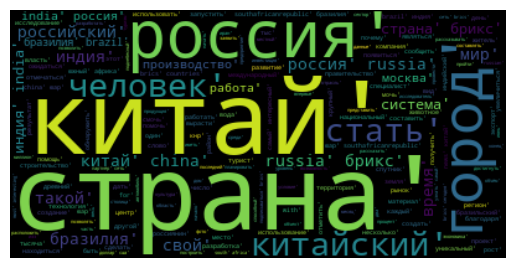

In [777]:
textt = ''.join(w for w in topic_1.tokens)
wordcloud = WordCloud().generate(textt)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

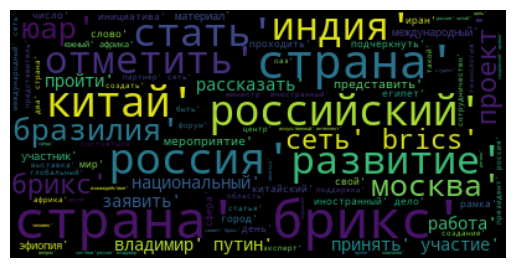

In [779]:
textt = ''.join(w for w in topic_2.tokens)
wordcloud = WordCloud().generate(textt)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [781]:
LDA = LatentDirichletAllocation(n_components=3, random_state=42)
LDA.fit(doc_term_matrix)
for i,topic in enumerate(LDA.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['брикс', 'india', 'город', 'brics', 'самый', 'россия', 'космический', 'russia', 'china', 'китай']


Top 10 words for topic #1:
['президент', 'пройти', 'российский', 'развитие', 'сотрудничество', 'международный', 'brics', 'россия', 'страна', 'брикс']


Top 10 words for topic #2:
['экспорт', 'достигнуть', 'производство', 'вырасти', 'россия', 'рост', 'бразилия', 'китай', 'страна', 'индия']




In [787]:
topic_values = LDA.transform(doc_term_matrix)
df['Topic_LDA'] = topic_values.argmax(axis=1)
topic_1 = df[df['Topic_LDA']==0]
topic_2 = df[df['Topic_LDA']==1]
topic_3 = df[df['Topic_LDA']==2]

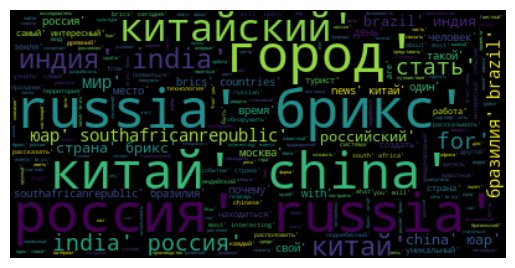

In [784]:
textt = ''.join(w for w in topic_1.tokens)
wordcloud = WordCloud().generate(textt)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

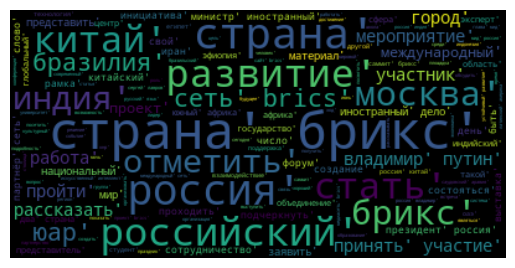

In [785]:
textt = ''.join(w for w in topic_2.tokens)
wordcloud = WordCloud().generate(textt)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

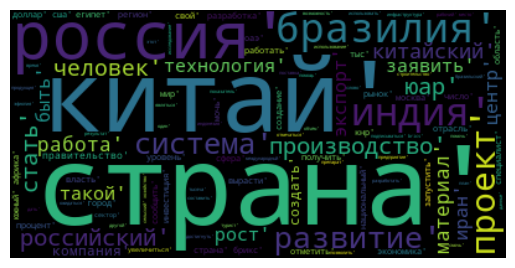

In [789]:
textt = ''.join(w for w in topic_3.tokens)
wordcloud = WordCloud().generate(textt)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [791]:
LDA = LatentDirichletAllocation(n_components=4, random_state=42)
LDA.fit(doc_term_matrix)
for i,topic in enumerate(LDA.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['древний', 'вода', 'земля', 'спутник', 'самый', 'вид', 'китайский', 'город', 'космический', 'китай']


Top 10 words for topic #1:
['мероприятие', 'пройти', 'российский', 'развитие', 'сотрудничество', 'международный', 'brics', 'россия', 'страна', 'брикс']


Top 10 words for topic #2:
['брикс', 'china', 'россия', 'russia', 'страна', 'юар', 'китай', 'бразилия', 'актуальный', 'индия']


Top 10 words for topic #3:
['процент', 'объём', 'страна', 'бразилия', 'составить', 'индия', 'достигнуть', 'рост', 'россия', 'вырасти']




In [799]:
topic_values = LDA.transform(doc_term_matrix)
df['Topic_LDA'] = topic_values.argmax(axis=1)
topic_1 = df[df['Topic_LDA']==0]
topic_2 = df[df['Topic_LDA']==1]
topic_3 = df[df['Topic_LDA']==2]
topic_4 = df[df['Topic_LDA']==3]

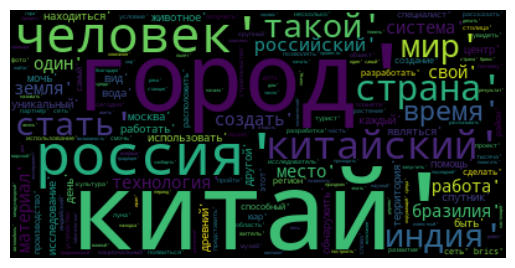

In [793]:
textt = ''.join(w for w in topic_1.tokens)
wordcloud = WordCloud().generate(textt)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

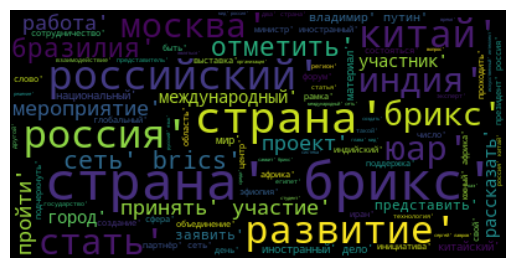

In [794]:
textt = ''.join(w for w in topic_2.tokens)
wordcloud = WordCloud().generate(textt)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

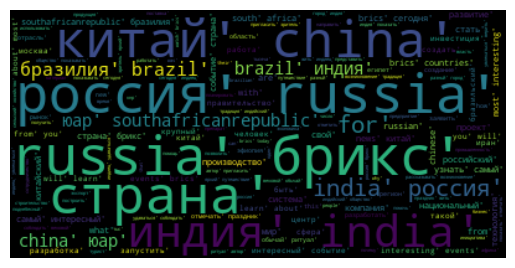

In [801]:
textt = ''.join(w for w in topic_3.tokens)
wordcloud = WordCloud().generate(textt)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

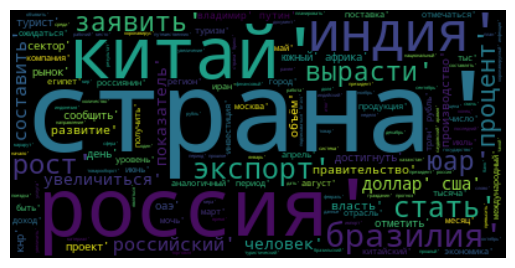

In [802]:
textt = ''.join(w for w in topic_4.tokens)
wordcloud = WordCloud().generate(textt)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [805]:
LDA = LatentDirichletAllocation(n_components=5, random_state=42)
LDA.fit(doc_term_matrix)
for i,topic in enumerate(LDA.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['время', 'провинция', 'китайский', 'космос', 'земля', 'город', 'станция', 'спутник', 'китай', 'космический']


Top 10 words for topic #1:
['русский', 'китайский', 'москва', 'культура', 'пройти', 'россия', 'страна', 'брикс', 'международный', 'brics']


Top 10 words for topic #2:
['международный', 'заявить', 'министр', 'президент', 'индия', 'сотрудничество', 'развитие', 'россия', 'брикс', 'страна']


Top 10 words for topic #3:
['подкаст', 'маршрут', 'россия', 'обнаружить', 'ограничение', 'турист', 'коронавирус', 'рейс', 'читать', 'время']


Top 10 words for topic #4:
['брикс', 'экспорт', 'юар', 'china', 'russia', 'вырасти', 'россия', 'индия', 'бразилия', 'китай']




In [806]:
topic_values = LDA.transform(doc_term_matrix)
df['Topic_LDA'] = topic_values.argmax(axis=1)
topic_1 = df[df['Topic_LDA']==0]
topic_2 = df[df['Topic_LDA']==1]
topic_3 = df[df['Topic_LDA']==2]
topic_4 = df[df['Topic_LDA']==3]
topic_5 = df[df['Topic_LDA']==4]

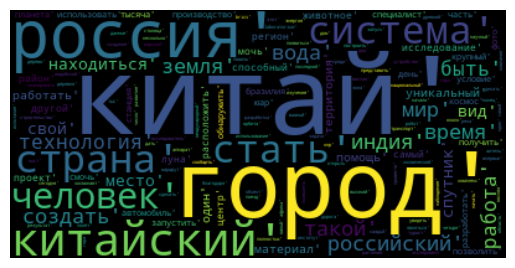

In [807]:
textt = ''.join(w for w in topic_1.tokens)
wordcloud = WordCloud().generate(textt)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

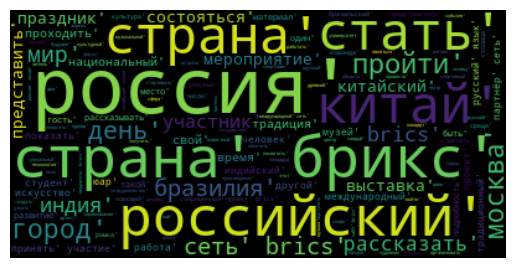

In [808]:
textt = ''.join(w for w in topic_2.tokens)
wordcloud = WordCloud().generate(textt)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

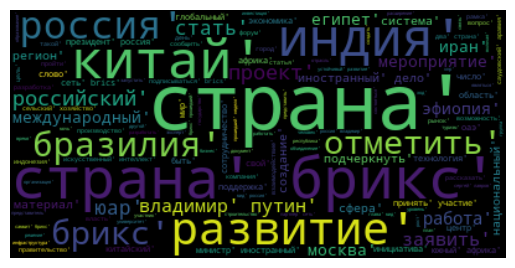

In [809]:
textt = ''.join(w for w in topic_3.tokens)
wordcloud = WordCloud().generate(textt)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

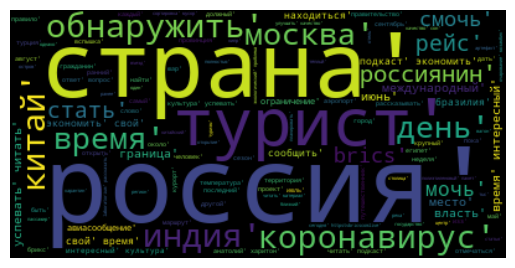

In [810]:
textt = ''.join(w for w in topic_4.tokens)
wordcloud = WordCloud().generate(textt)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

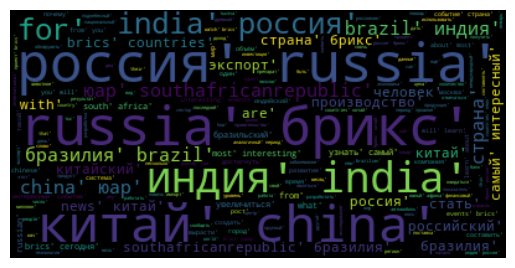

In [812]:
textt = ''.join(w for w in topic_5.tokens)
wordcloud = WordCloud().generate(textt)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()